In [1]:

# %% [markdown]

# Imports

# %%

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
import csv
import random
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

import pandas as pd
import numpy as np

from torchvision import models


In [ ]:

# %% [markdown]

# Configutation

# %%

@dataclass
class CFG:


    # données
    data_dir: str = "./data"

    # critère de perte 
    mse_weight = 1.0
    feature_weight = 0.1
    style_weight = 0.05
    vgg_resize = 64
    layer = "relu2_2"

    #modèle
    base_ch = 64
        
    #entrainement
    batch_size: int = 256
    num_workers: int = 0
    epochs: int = 100
    lr: float = 3e-3
    weight_decay: float = 0.0
    seed: int = 42

    # bruit
    noises: tuple = ("gaussian", "speckle")
    split_mode: str = "half"
    gaussian_std: float = 0.12
    speckle_std: float = 0.35

    # sauvegardes
    out_dir: str = "./out_cifar10_denoise"
    model_path: str = "denoiser_cifar10.pt"
    losses_path: str = "losses.csv"
    examples_path: str = "cifar10_examples.pt"


cfg = CFG()

def set_seed(seed: int):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True  # perf
set_seed(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

os.makedirs(cfg.out_dir, exist_ok=True)
cfg.model_path = os.path.join(cfg.out_dir, cfg.model_path)
cfg.losses_path = os.path.join(cfg.out_dir, cfg.losses_path)
cfg.examples_path = os.path.join(cfg.out_dir, cfg.examples_path)


Device: cuda


In [ ]:

# %% [markdown]

# Dataset wrapper

# %%

class NoisedCIFAR10(Dataset):
    """
    Retourne: (x_noisy, x_clean, y)
    x_clean et x_noisy: float32 [0,1], shape (3,32,32)
    """
    def __init__(self, base_ds,
        noises=("gaussian", "speckle"),
        split_mode="half",
        gaussian_std=0.12,
        speckle_std=0.35):
        self.base = base_ds
        self.noises = noises
        self.split_mode = split_mode
        self.split = len(base_ds) // 2
        self.gaussian_std = gaussian_std
        self.speckle_std = speckle_std

    
    @torch.no_grad()
    def add_noise(self, x, noise_type: str, seed):
        torch.manual_seed(seed)
        if noise_type == "gaussian":
            n = torch.randn_like(x) * self.gaussian_std
            return (x + n).clamp(0, 1)

        if noise_type == "speckle":
            n = torch.randn_like(x) * self.speckle_std
            return (x + x * n).clamp(0, 1)

        raise ValueError(noise_type)

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x_clean, y = self.base[idx]  # tensor [0,1]
        if self.split_mode == "half":
            noise_type = self.noises[0] if idx < self.split else self.noises[1]
        elif self.split_mode == "random":
            noise_type = random.choice(self.noises)
        else:
            raise ValueError("split_mode must be 'half' or 'random'")

        x_noisy = self.add_noise(x_clean, noise_type, seed=idx)
        return x_noisy, x_clean, y



In [ ]:

# %% [markdown]

# Modèle U-Net

# %%

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.ReLU(inplace=True),
    )

    
    def forward(self, x):
        return self.net(x)


class UNetLight(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base_ch=32):
        super().__init__()


        # Encoder
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DoubleConv(base_ch, base_ch*2)
        self.enc3 = DoubleConv(base_ch*2, base_ch*4)

        # Bottleneck
        self.bottleneck = DoubleConv(base_ch*2, base_ch*4)

        # Decoder
        self.dec3 = DoubleConv(base_ch*4, base_ch*4)
        self.dec2 = DoubleConv(base_ch*4 + base_ch*2, base_ch*2)
        self.dec1 = DoubleConv(base_ch*2 + base_ch, base_ch)

        self.out = nn.Conv2d(base_ch, out_ch, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x) 
        e2 = self.enc2(F.max_pool2d(e1, 2))
        e3 = self.enc3(F.max_pool2d(e2, 2))

        # Bottleneck
        b = self.bottleneck(F.max_pool2d(e3, 2))

        # Decoder
        d3 = F.interpolate(b, scale_factor=2, mode="nearest")
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = F.interpolate(d3, scale_factor=2, mode="nearest")
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = F.interpolate(d2, scale_factor=2, mode="nearest")
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.out(d1))



In [5]:

# %% [markdown]

# Création du dataset

# %%

tfm = transforms.ToTensor()

train_base = datasets.CIFAR10(cfg.data_dir, train=True, download=True, transform=tfm)
test_base  = datasets.CIFAR10(cfg.data_dir, train=False, download=True, transform=tfm)

train_ds = NoisedCIFAR10(
    train_base,
    noises=cfg.noises,
    split_mode=cfg.split_mode,
    gaussian_std=cfg.gaussian_std,
    speckle_std=cfg.speckle_std,
)
test_ds = NoisedCIFAR10(
    test_base,
    noises=cfg.noises,
    split_mode=cfg.split_mode,
    gaussian_std=cfg.gaussian_std,
    speckle_std=cfg.speckle_std,
)

pin_memory = (device.type == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)


C:\Users\thoma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [ ]:

# %% [markdown]

# Train utils

# %%

@torch.no_grad()
def psnr_from_mse(mse):
    # PSNR = 10 log10( MAX^2 / MSE ), MAX=1
    return 10.0 * torch.log10(1.0 / torch.clamp(mse, min=1e-12))

@torch.no_grad()
def eval_on_loader(model, loader, criterion, device):
    model.eval()
    total_loss, total_psnr, n_batches = 0.0, 0.0, 0
    for noisy, clean, _ in loader:
        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)
        out = model(noisy)
        loss = criterion(out, clean)
        total_loss += loss.item()
        total_psnr += psnr_from_mse(loss.detach()).item()
        n_batches += 1
    return total_loss / max(n_batches, 1)


mse_metric = nn.MSELoss()

@torch.no_grad()
def eval_mse_psnr(model, loader, device):
    model.eval()
    mse_sum, n_batches = 0.0, 0
    for noisy, clean, _ in loader:
        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)
        out = model(noisy)
        mse = mse_metric(out, clean)
        mse_sum += mse.item()
        n_batches += 1
    mse_avg = mse_sum / max(n_batches, 1)
    psnr = 10.0 * torch.log10(torch.tensor(1.0) / torch.clamp(torch.tensor(mse_avg), min=1e-12))
    return float(psnr)


In [7]:

# %% [markdown]

# VGG16 feature extractor (changeable layer)

# %%

def make_vgg16_feature_extractor(layer="relu2_2", device="cuda"):
    """
    Retourne un nn.Module qui sort les features à une couche VGG16 donnée.
    Entrée attendue: images RGB normalisées ImageNet.
    """
    vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features

    
    # Mapping couche -> index dans vgg.features
    # VGG16 features indices (conv/relu/pool):
    # relu1_1: 1, relu1_2: 3, pool1: 4
    # relu2_1: 6, relu2_2: 8, pool2: 9
    # relu3_1: 11, relu3_2: 13, relu3_3: 15, pool3: 16
    # relu4_1: 18, relu4_2: 20, relu4_3: 22, pool4: 23
    # relu5_1: 25, relu5_2: 27, relu5_3: 29, pool5: 30
    layer_to_idx = {
        "relu1_1": 1, "relu1_2": 3,
        "relu2_1": 6, "relu2_2": 8,
        "relu3_1": 11, "relu3_2": 13, "relu3_3": 15,
        "relu4_1": 18, "relu4_2": 20, "relu4_3": 22,
        "relu5_1": 25, "relu5_2": 27, "relu5_3": 29,
    }
    if layer not in layer_to_idx:
        raise ValueError(f"Unknown layer {layer}. Choose one of: {list(layer_to_idx.keys())}")

    cut_idx = layer_to_idx[layer]
    extractor = nn.Sequential(*[vgg[i] for i in range(cut_idx + 1)])

    # geler les poids
    for p in extractor.parameters():
        p.requires_grad = False

    extractor.eval().to(device)
    return extractor


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)


In [8]:

# %% [markdown]

# Criterion with MSE, Feature Loss and Style Loss

# %%

class DenoisingLoss(nn.Module):
    def __init__(self, feature_extractor, device,
        mse_weight=1.0, feature_weight=0.1, style_weight=0.1,
        vgg_resize=64):
        super().__init__()
        self.mse_weight = mse_weight
        self.feature_weight = feature_weight
        self.style_weight = style_weight
        self.mse_loss = nn.MSELoss()
        self.feature_extractor = feature_extractor
        self.device = device
        self.vgg_resize = vgg_resize


        self.feature_extractor.eval()
        for p in self.feature_extractor.parameters():
            p.requires_grad = False

        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406], device=self.device).view(1,3,1,1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225], device=self.device).view(1,3,1,1))

    def preprocess_for_vgg(self, x):
        # x: (B,3,H,W) in [0,1]
        x = nn.functional.interpolate(x, size=(self.vgg_resize, self.vgg_resize),
                                    mode="bilinear", align_corners=False)
        x = (x - self.mean) / self.std
        return x

    def gram_matrix(self, features):
        features = features.float()
        b, c, h, w = features.size()
        f = features.view(b, c, h*w)
        gram = torch.bmm(f, f.transpose(1, 2)) / (c * h * w)
        return gram


    def forward(self, output, target):
        mse = self.mse_loss(output, target)

        # do VGG + style in fp32 to avoid fp16 overflow
        with torch.amp.autocast("cuda", enabled=False):
            out_vgg = self.preprocess_for_vgg(output.float())
            tgt_vgg = self.preprocess_for_vgg(target.float())

            with torch.no_grad():
                tgt_feat = self.feature_extractor(tgt_vgg)
            out_feat = self.feature_extractor(out_vgg)

            feature_loss = self.mse_loss(out_feat, tgt_feat)

            tgt_gram = self.gram_matrix(tgt_feat)
            out_gram = self.gram_matrix(out_feat)
            style_loss = self.mse_loss(out_gram, tgt_gram)

        total = (self.mse_weight * mse +
                self.feature_weight * feature_loss +
                self.style_weight * style_loss)
        return total


In [ ]:


# %% [markdown]

# Training

# %%

model = UNetLight(base_ch=cfg.base_ch).to(device)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {params/1e6:.2f} M")

feature_extractor = make_vgg16_feature_extractor(cfg.layer, device=device)
feature_extractor = feature_extractor.to(device).eval()
for p in feature_extractor.parameters():
    p.requires_grad = False

criterion = DenoisingLoss(feature_extractor=feature_extractor, mse_weight=cfg.mse_weight, feature_weight=cfg.feature_weight, style_weight=cfg.style_weight, vgg_resize=cfg.vgg_resize, device=device)
optimizer = optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

losses_train = []
losses_test = []
psnr_test = []

best_test_loss = float("inf")
best_epoch = -1

# Path where the best checkpoint will be saved

best_ckpt_path = getattr(cfg, "best_ckpt_path", None)
if best_ckpt_path is None:
    out_dir = getattr(cfg, "out_dir", ".")
os.makedirs(out_dir, exist_ok=True)
best_ckpt_path = os.path.join(out_dir, "best_model.pt")

patience = 10

for epoch in range(cfg.epochs):
    model.train()
    running = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")
    for noisy, clean, _ in pbar:
        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            out = model(noisy)
            loss = criterion(out, clean)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_train = running / len(train_loader)
    t_loss, t_psnr = eval_on_loader(model, test_loader, criterion), eval_mse_psnr(model, test_loader, device)

    losses_train.append(avg_train)
    losses_test.append(t_loss)
    psnr_test.append(t_psnr)

    if t_loss < best_test_loss:
        best_test_loss = t_loss
        best_epoch = epoch

        ckpt = {
            "epoch": epoch,
            "best_test_loss": best_test_loss,
            "model_state_dict": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            "optimizer_state_dict": optimizer.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
        }
        torch.save(ckpt, best_ckpt_path)

    print(
        f"Epoch {epoch+1}/{cfg.epochs} | "
        f"train loss: {avg_train:.6f} | test loss: {t_loss:.6f} | test PSNR: {t_psnr:.2f} dB"
    )

    # Early stopping
    if best_epoch != -1 and (epoch - best_epoch) >= patience:
        print(
            f"Early stopping at epoch {epoch+1}. "
            f"Best epoch was {best_epoch+1} with test loss {best_test_loss:.6f}."
        )
        # Restore best model from disk
        best_ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state_dict"])
        break

    scheduler.step()


if os.path.exists(best_ckpt_path):
    best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Restored best checkpoint from: {best_ckpt_path} (epoch {best_ckpt['epoch']+1})")


Model parameters: 1.88 M


Epoch 1/100: 100%|██████████| 98/98 [00:59<00:00,  1.64it/s, loss=0.227]


Epoch 1/100 | train loss: 0.289749 | test loss: 0.213270 | test PSNR: 6.71 dB


Epoch 2/100: 100%|██████████| 98/98 [00:52<00:00,  1.86it/s, loss=0.211]


Epoch 2/100 | train loss: 0.217856 | test loss: 0.199309 | test PSNR: 7.00 dB


...

Epoch 93/100: 100%|██████████| 98/98 [00:52<00:00,  1.86it/s, loss=0.179]


Epoch 93/100 | train loss: 0.177797 | test loss: 0.170077 | test PSNR: 7.69 dB


Epoch 94/100: 100%|██████████| 98/98 [00:52<00:00,  1.87it/s, loss=0.177]


Epoch 94/100 | train loss: 0.177635 | test loss: 0.169792 | test PSNR: 7.70 dB
Early stopping at epoch 94. Best epoch was 84 with test loss 0.169582.
Restored best checkpoint from: ./out_cifar10_denoise\best_model.pt (epoch 84)


ValueError: I/O operation on closed file.

In [10]:

# Save losses to CSV

with open(cfg.losses_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "test_loss", "test_psnr"])
    for epoch in range(len(losses_train)):
        writer.writerow([epoch+1, losses_train[epoch], losses_test[epoch], psnr_test[epoch]])


Device: cuda
Loaded best checkpoint: ./out_cifar10_denoise\best_model.pt (epoch 84, best test loss=0.169582)


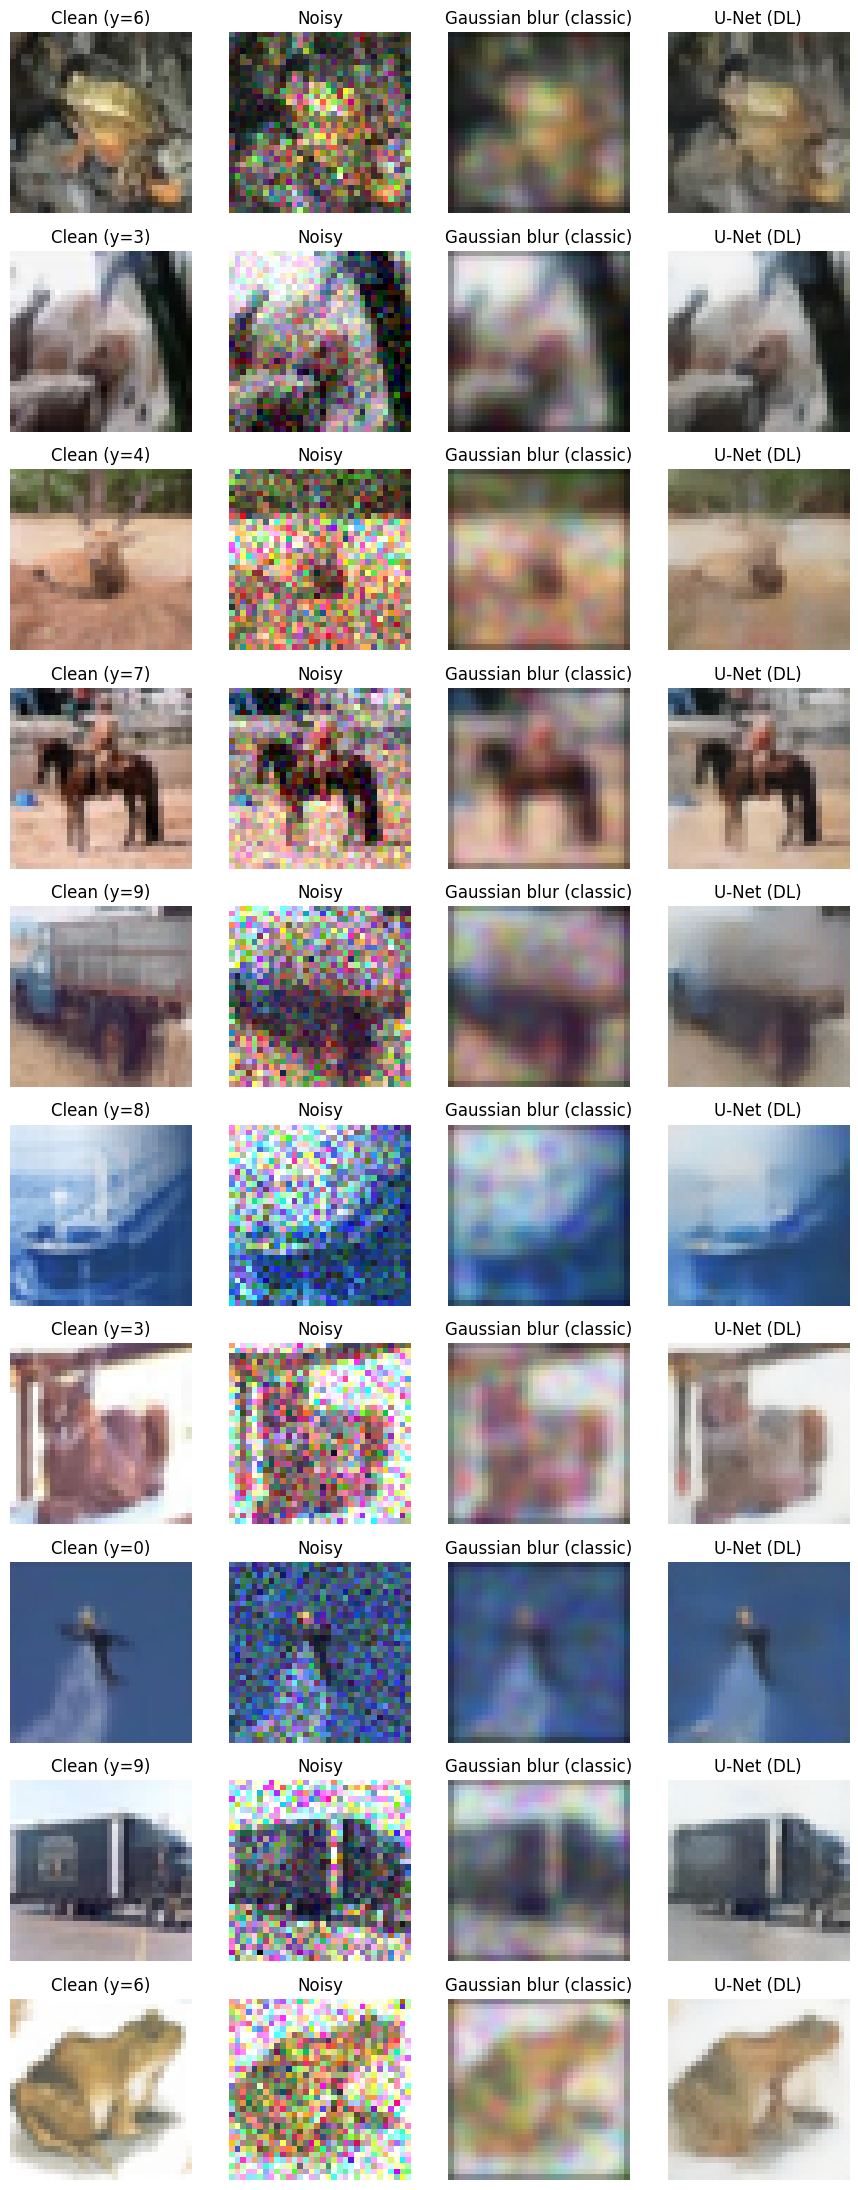

In [15]:
# %%
# -----------------------------
# Post-training: load best checkpoint + visualize denoising examples
# + classical (non-DL) convolutional denoising baseline (Gaussian blur)
# -----------------------------

import os
import math
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ---------- 1) Re-declare the model classes (must match training) ----------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class UNetLight(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base_ch=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base_ch)
        self.enc2 = DoubleConv(base_ch, base_ch * 2)
        self.bottleneck = DoubleConv(base_ch * 2, base_ch * 4)
        self.dec2 = DoubleConv(base_ch * 4 + base_ch * 2, base_ch * 2)
        self.dec1 = DoubleConv(base_ch * 2 + base_ch, base_ch)
        self.out = nn.Conv2d(base_ch, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(F.max_pool2d(e1, 2))
        b = self.bottleneck(F.max_pool2d(e2, 2))
        d2 = F.interpolate(b, scale_factor=2, mode="nearest")
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = F.interpolate(d2, scale_factor=2, mode="nearest")
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return torch.sigmoid(self.out(d1))

# ---------- 2) Classical non-DL baseline: Gaussian blur via conv2d ----------
def gaussian_kernel2d(kernel_size: int = 7, sigma: float = 1.2, device="cpu", dtype=torch.float32):
    """
    Returns a (1,1,ks,ks) Gaussian kernel normalized to sum=1.
    """
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be odd")
    ax = torch.arange(kernel_size, device=device, dtype=dtype) - kernel_size // 2
    xx, yy = torch.meshgrid(ax, ax, indexing="ij")
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    return kernel.view(1, 1, kernel_size, kernel_size)

@torch.no_grad()
def gaussian_blur_conv(x: torch.Tensor, kernel_size: int = 7, sigma: float = 1.2) -> torch.Tensor:
    """
    x: (B,C,H,W) in [0,1]
    Applies same Gaussian blur independently to each channel.
    """
    device = x.device
    dtype = x.dtype
    k = gaussian_kernel2d(kernel_size, sigma, device=device, dtype=dtype)  # (1,1,ks,ks)
    C = x.shape[1]
    k = k.repeat(C, 1, 1, 1)  # (C,1,ks,ks)
    pad = kernel_size // 2
    return F.conv2d(x, k, padding=pad, groups=C).clamp(0, 1)

# ---------- 3) Paths ----------
out_dir = cfg.out_dir if "cfg" in globals() and hasattr(cfg, "out_dir") else "./out_cifar10_denoise"
best_ckpt_path = os.path.join(out_dir, "best_model.pt")
if not os.path.exists(best_ckpt_path):
    raise FileNotFoundError(f"Checkpoint not found: {best_ckpt_path}")

# ---------- 4) Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ---------- 5) Load checkpoint ----------
base_ch = cfg.base_ch if "cfg" in globals() and hasattr(cfg, "base_ch") else 32
model = UNetLight(base_ch=base_ch).to(device)

ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint: {best_ckpt_path} (epoch {ckpt['epoch']+1}, best test loss={ckpt['best_test_loss']:.6f})")

# ---------- 6) Dataset / loader (for visualization only) ----------
if "NoisedCIFAR10" not in globals():
    class NoisedCIFAR10(torch.utils.data.Dataset):
        def __init__(self, base_ds, noises=("gaussian","speckle"), split_mode="half", gaussian_std=0.12, speckle_std=0.35):
            self.base = base_ds
            self.noises = noises
            self.split_mode = split_mode
            self.split = len(base_ds) // 2
            self.gaussian_std = gaussian_std
            self.speckle_std = speckle_std

        @torch.no_grad()
        def add_noise(self, x, noise_type):
            if noise_type == "gaussian":
                n = torch.randn_like(x) * self.gaussian_std
                return (x + n).clamp(0, 1)
            if noise_type == "speckle":
                n = torch.randn_like(x) * self.speckle_std
                return (x + x * n).clamp(0, 1)
            raise ValueError(noise_type)

        def __len__(self):
            return len(self.base)

        def __getitem__(self, idx):
            x_clean, y = self.base[idx]
            if self.split_mode == "half":
                noise_type = self.noises[0] if idx < self.split else self.noises[1]
            elif self.split_mode == "random":
                noise_type = random.choice(self.noises)
            else:
                raise ValueError("split_mode must be 'half' or 'random'")
            x_noisy = self.add_noise(x_clean, noise_type)
            return x_noisy, x_clean, y

tfm = transforms.ToTensor()
test_base = datasets.CIFAR10(cfg.data_dir if "cfg" in globals() else "./data",
                            train=False, download=True, transform=tfm)

noises = cfg.noises if "cfg" in globals() and hasattr(cfg, "noises") else ("gaussian","speckle")
split_mode = cfg.split_mode if "cfg" in globals() and hasattr(cfg, "split_mode") else "half"
gauss_std = cfg.gaussian_std if "cfg" in globals() and hasattr(cfg, "gaussian_std") else 0.12
speck_std = cfg.speckle_std if "cfg" in globals() and hasattr(cfg, "speckle_std") else 0.35

test_ds = NoisedCIFAR10(test_base, noises=noises, split_mode=split_mode,
                        gaussian_std=gauss_std, speckle_std=speck_std)

vis_loader = DataLoader(test_ds, batch_size=10, shuffle=True,
                        num_workers=0, pin_memory=(device.type == "cuda"))

# ---------- 7) Get one batch ----------
noisy, clean, labels = next(iter(vis_loader))

# DL denoising
with torch.no_grad():
    denoised_dl = model(noisy.to(device)).cpu()

# Classical baseline (Gaussian blur) - run on CPU tensors (or GPU if you move noisy)
with torch.no_grad():
    # If you want it on GPU: noisy.to(device) then .cpu() afterwards
    denoised_blur = gaussian_blur_conv(noisy, kernel_size=7, sigma=1.2)

# ---------- 8) Plot: N rows, 4 columns (Clean / Noisy / Blur / UNet) ----------
def chw_to_hwc(x):
    return x.permute(1, 2, 0).clamp(0, 1)

N = noisy.size(0)
fig, axes = plt.subplots(N, 4, figsize=(9, 2.2 * N))

for i in range(N):
    axes[i, 0].imshow(chw_to_hwc(clean[i]))
    axes[i, 0].set_title(f"Clean (y={int(labels[i])})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(chw_to_hwc(noisy[i]))
    axes[i, 1].set_title("Noisy")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(chw_to_hwc(denoised_blur[i]))
    axes[i, 2].set_title("Gaussian blur (classic)")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(chw_to_hwc(denoised_dl[i]))
    axes[i, 3].set_title("U-Net (DL)")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()
